### Reglas de formato y presentación
- El trabajo debe estar bien comentado (utilizando #) para que el código sea fácil de entender por sus compañeros y profesores.

- El mismo debe ser completado en este Jupyter Notebook y entregado como tal, es decir en un archivo .ipynb


# Big Data
## Trabajo Práctico 2

### Modalidad de entrega
- Al finalizar el trabajo práctico deben hacer un último <i>commit</i> en su repositorio de GitHub con el mensaje “Entrega final del tp”.
- Asegurense de haber creado una carpeta llamada TP2
- La última versión en el repositorio es la que será evaluada. Por lo que es importante que:
    - No hagan nuevos <i>push</i> despues de haber entregado su versión final. Esto generaría confusión acerca de que versión es la que quieren que se les corrija.

### Fecha de entrega:
Viernes 24 de octubre a las 23:59hs

### Parte A

#### Ejercicio 1
Usando la API de Yahoo Finance, obtener la serie de alguna acción. Pueden buscar cualquier acción de su interés.

In [ ]:
# Seguimos los pasos iniciales de la Tutorial:

import requests
from urllib.parse import quote_plus

# Paso 1: Definir la URL y los parámetros de búsqueda
    # Yahoo Finance URL: https://query1.finance.yahoo.com/v1/finance/search?q=BUSCAR
    # BUSCAR: ticker a buscar
buscar = "MercadoLibre" # Podría ser cualquier ticker, por ejemplo YPF, MSFT, IBM, etc.
url = "https://query1.finance.yahoo.com/v1/finance/search?q={}".format(quote_plus(buscar))

# Encabezado para parecer más "humanos" y evitar bloqueos
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/141.0.0.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
}

# Request y response
response = requests.request("GET", url, headers=headers)
#response = requests.request("GET", url) # Vemos que sin header devuelve error de muchos requests
print(response) # correcto

# Vemos el texto
response.text[:] # Imprimimos solo los primeros caracteres

# Código para ver cuál es la url
url # https://query1.finance.yahoo.com/v1/finance/search?q=MercadoLibre

<Response [200]>


'{"explains":[],"count":15,"quotes":[{"exchange":"NMS","shortname":"MercadoLibre, Inc.","quoteType":"EQUITY","symbol":"MELI","index":"quotes","score":20134.0,"typeDisp":"Equity","longname":"MercadoLibre, Inc.","exchDisp":"NASDAQ","sector":"Consumer Cyclical","sectorDisp":"Consumer Cyclical","industry":"Internet Retail","industryDisp":"Internet Retail","dispSecIndFlag":true,"isYahooFinance":true},{"exchange":"GER","shortname":"Mercadolibre Inc.             R","quoteType":"EQUITY","symbol":"MLB1.DE","index":"quotes","score":20001.0,"typeDisp":"Equity","longname":"MercadoLibre, Inc.","exchDisp":"XETRA","sector":"Consumer Cyclical","sectorDisp":"Consumer Cyclical","industry":"Internet Retail","industryDisp":"Internet Retail","isYahooFinance":true},{"exchange":"VIE","shortname":"MERCADOLIBRE INC","quoteType":"EQUITY","symbol":"MELI.VI","index":"quotes","score":20001.0,"typeDisp":"Equity","longname":"MercadoLibre, Inc.","exchDisp":"Vienna","sector":"Consumer Cyclical","sectorDisp":"Consumer 

In [3]:
# Ahora pasamos al ajuste de la búsqueda para la acción específica de MercadoLibre:
symbol = "MELI" # Ticker de la acción
range = "1y" # Dado que no se especifica, tomamos 1 año como en la tutorial
interval = "1mo" # Intervalo mensual, como en la tutorial

# v8 y chart, que devuelve series
url = f" https://query1.finance.yahoo.com/v8/finance/chart/{symbol}?range={range}&interval={interval}"

response = requests.request("GET", url, headers=headers)

print(response)

data = response.json()

# json de la acción MELI
data

<Response [200]>


{'chart': {'result': [{'meta': {'currency': 'USD',
     'symbol': 'MELI',
     'exchangeName': 'NMS',
     'fullExchangeName': 'NasdaqGS',
     'instrumentType': 'EQUITY',
     'firstTradeDate': 1186752600,
     'regularMarketTime': 1760983727,
     'hasPrePostMarketData': True,
     'gmtoffset': -14400,
     'timezone': 'EDT',
     'exchangeTimezoneName': 'America/New_York',
     'regularMarketPrice': 2085.0,
     'fiftyTwoWeekHigh': 2645.22,
     'fiftyTwoWeekLow': 1646.0,
     'regularMarketDayHigh': 2090.0,
     'regularMarketDayLow': 2033.09,
     'regularMarketVolume': 204722,
     'longName': 'MercadoLibre, Inc.',
     'shortName': 'MercadoLibre, Inc.',
     'chartPreviousClose': 2079.79,
     'priceHint': 2,
     'currentTradingPeriod': {'pre': {'timezone': 'EDT',
       'end': 1760967000,
       'start': 1760947200,
       'gmtoffset': -14400},
      'regular': {'timezone': 'EDT',
       'end': 1760990400,
       'start': 1760967000,
       'gmtoffset': -14400},
      'post': 

In [4]:
# Usamos las keys del diccionario
chart = data["chart"]["result"][0]
timestamps = chart["timestamp"]
closes = chart["indicators"]["quote"][0]["close"]

# Convertimos los datos a un dataframe de pandas
import pandas as pd
from datetime import datetime

dates = [datetime.fromtimestamp(ts) for ts in timestamps] # Cambiamos el formato de la fecha

# Armamos el df
df = pd.DataFrame({
    "Date": dates,
    "Close": closes # el valor de interés de la acción
})

df.set_index("Date", inplace=True)

df # este es el resultado buscado, la serie de la acción 'MELI', de MercadoLibre.

,Close
Date,
2024-11-01 01:00:00,1985.170044
2024-12-01 02:00:00,1700.439941
2025-01-01 02:00:00,1922.189941
2025-02-01 02:00:00,2121.870117
2025-03-01 02:00:00,1950.869995
2025-04-01 01:00:00,2330.850098
2025-05-01 01:00:00,2563.290039
2025-06-01 01:00:00,2613.629883
2025-07-01 01:00:00,2373.889893


#### Ejercicio 2
Guarden los precios de los ítems obtenidos en un dataframe y calculen el precio promedio, el mínimo y el máximo.

In [5]:
# DataFrame del close de MELI
close_series = df['Close'].dropna()

# Calculamos las estadísticas solicitadas
mean_price = close_series.mean()
min_price = close_series.min()
max_price = close_series.max()

# Imprimimos
print(f'Precio promedio: {mean_price}')
print(f'Precio mínimo: {min_price}')
print(f'Precio máximo: {max_price}')

Precio promedio: 2190.9253680889424
Precio mínimo: 1700.43994140625
Precio máximo: 2613.6298828125


#### Ejercicio 3
Armen un histograma de los precios usando Matplotlib. ¿Ven algún <i>outlier<i>?

Matplotlib is building the font cache; this may take a moment.


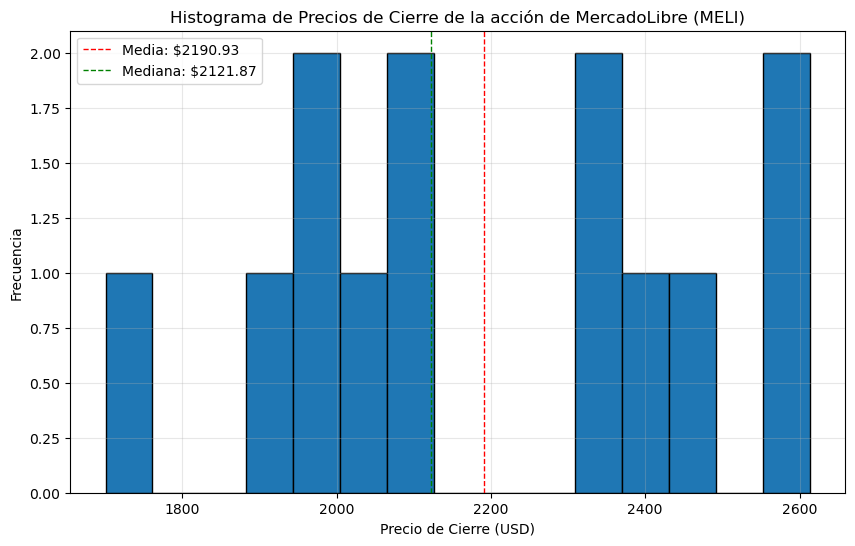

Análisis de Outliers:
Rango normal de precios: $1402.09 - $2956.97
No se encontraron outliers según el criterio del IQR.


In [ ]:
# Histograma

# Importamos matplotlib
import matplotlib.pyplot as plt

# Creamos el histograma
plt.figure(figsize=(10, 6))  # Tamaño de la figura
plt.hist(df['Close'].dropna(), bins=15, edgecolor='black')  # dropna() para eliminar valores missing si los hay

# Personalizamos el gráfico
plt.title('Histograma de Precios de Cierre de la acción de MercadoLibre (MELI)')
plt.xlabel('Precio de Cierre (USD)')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)  # Grid con transparencia

# Agregamos líneas verticales para precio promedio y mediana
plt.axvline(df['Close'].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Media: ${df["Close"].mean():.2f}')
plt.axvline(df['Close'].median(), color='green', linestyle='dashed', linewidth=1, label=f'Mediana: ${df["Close"].median():.2f}')

plt.legend()
plt.show()


# Análisis de outliers

# Usamos el método del rango intercuartílico (IQR)
Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)
IQR = Q3 - Q1

# Definimos los límites para outliers
lower_bound = Q1 - 1.5 * IQR # mínimo valor "normal" de precios de MELI
upper_bound = Q3 + 1.5 * IQR # máximo valor "normal" de precios de MELI

# Identificamos outliers
outliers = df[(df['Close'] < lower_bound) | (df['Close'] > upper_bound)] # fuera del rango "normal" de precios de MELI

print("Análisis de Outliers:")
print(f"Rango normal de precios: ${lower_bound:.2f} - ${upper_bound:.2f}")
if not outliers.empty:
    print("Outliers encontrados:")
    print(outliers)
else:
    print("No se encontraron outliers según el criterio del IQR.")

#### Ejercicio 4
Busquen una api que no se haya trabajado en clase y realicen un request. Puede ser cualquier api, por ejemplo hay una api climática llamada Open Meteo, Spotify, etc. Expliquen los pasos que siguen.

Realizando request a Open Meteo API...
Status code: 200
Primeros registros del pronóstico:
Status code: 200
Primeros registros del pronóstico:
                 time  temperature
0 2025-10-20 00:00:00         15.7
1 2025-10-20 01:00:00         15.7
2 2025-10-20 02:00:00         15.7
3 2025-10-20 03:00:00         15.5
4 2025-10-20 04:00:00         15.0
                 time  temperature
0 2025-10-20 00:00:00         15.7
1 2025-10-20 01:00:00         15.7
2 2025-10-20 02:00:00         15.7
3 2025-10-20 03:00:00         15.5
4 2025-10-20 04:00:00         15.0


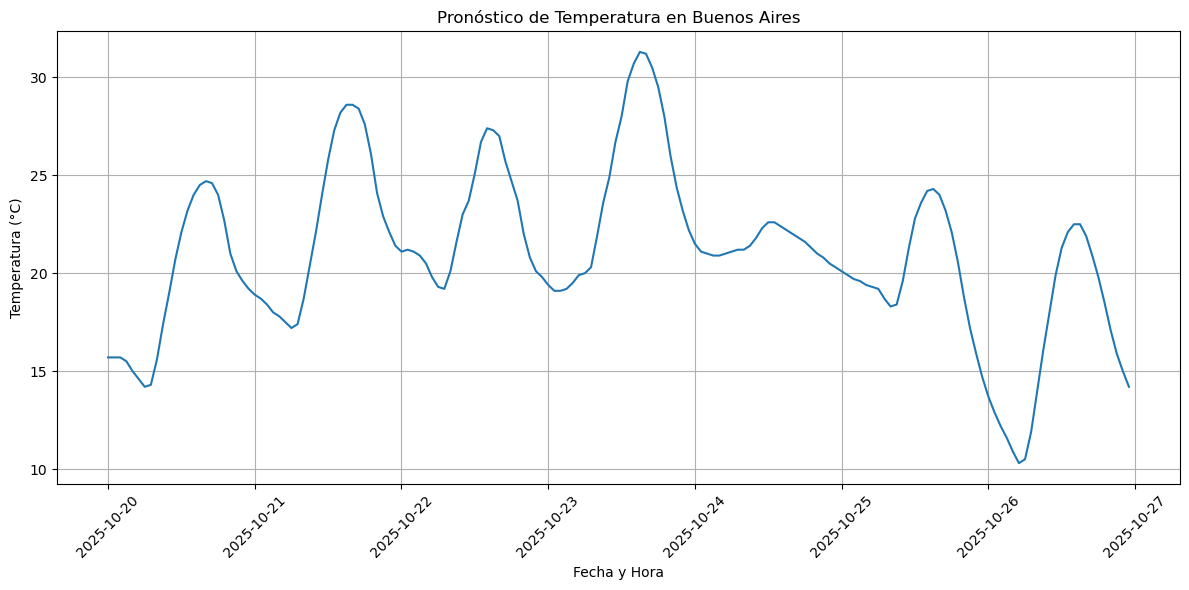


Estadísticas del pronóstico:
Temperatura máxima: 31.3°C
Temperatura mínima: 10.3°C
Temperatura promedio: 21.0°C


In [ ]:
# Usamos la API de Open Meteo para datos meteorológicos. Como pasos para este ejericio, hacemos:
#     1. Importamos librerías.
#     2. Definimos parámetros de la API (coordenadas de Buenos Aires).
#     3. Construimos la URL de la API.
#     4. Realizamos el request.
#     5. Procesamos la response.
#     (Extra: gráfico de temperaturas + estadísticos descriptivas básicas).

# 1. Importamos las librerías necesarias
import requests
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

# 2. Definimos los parámetros de la API
# Coordenadas de Buenos Aires
latitude = -34.6037
longitude = -58.3816

# 3. Construimos la URL de la API
# Documentación: https://open-meteo.com/en/docs
open_mateo_url = "https://api.open-meteo.com/v1/forecast"
pars = {
    "latitude": latitude,
    "longitude": longitude,
    "hourly": "temperature_2m",  # temperatura cada hora
    "timezone": "America/Argentina/Buenos_Aires"  # zona horaria local
}

# 4. Realizamos el request
print("Realizando request a Open Meteo API...")
response = requests.get(open_mateo_url, params=pars)
print(f"Status code: {response.status_code}")  # 200 significa éxito

# 5. Procesamos la response en un if que si está ok la procesa exitosamente y sino, devuelve mensaje de error.
if response.status_code == 200:
    data = response.json()
    
    # Crear DataFrame con los datos
    df_weather = pd.DataFrame({
        'time': pd.to_datetime(data['hourly']['time']),
        'temperature': data['hourly']['temperature_2m']
    })
    
    # Los primeros registros
    print("Primeros registros del pronóstico:")
    print(df_weather.head())
    

    # Extra: No está explícito en consigna pero añadimos por si es útil: gráfico de temperaturas + estadísticos descriptivas básicas.

    # Visualizamos los datos
    plt.figure(figsize=(12, 6))
    plt.plot(df_weather['time'], df_weather['temperature'])
    plt.title('Pronóstico de Temperatura en Buenos Aires')
    plt.xlabel('Fecha y Hora')
    plt.ylabel('Temperatura (°C)')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Estadísticas descriptivas básicas
    print("\nEstadísticas del pronóstico:")
    print(f"Temperatura máxima: {df_weather['temperature'].max():.1f}°C")
    print(f"Temperatura mínima: {df_weather['temperature'].min():.1f}°C")
    print(f"Temperatura promedio: {df_weather['temperature'].mean():.1f}°C")

# else: mensaje de error
else:
    print(f"Error en la solicitud: {response.status_code}")
    print(response.text)

### Parte B

#### Ejercicio 5
De la página de noticias de [Infobae](https://www.infobae.com/), utilicen herramientas de web scraping para obtener los links de las noticias de la portada. Guarden los links obtenidos en un dataframe y expórtenlo a un archivo de excel.

Nota 1: es posible que logren obtener los links a las noticias sin el dominio: "https://www.infobae.com/". De ser así, concatenen el dominio a la ruta del link obtenido, tal que se obtenga un link al que se pueda acceder. Es decir, que las cadenas de caracteres finales tendrán la forma: https://www.infobae.com/*texto_obtenido*)

Nota 2: junto con su entrega, adjunten una captura de la página de noticias al momento de correr su código. Eso servirá al momento de la corrección para verificar que los links obtenidos hacen referencia a las noticias de ese día y hora.

#### Ejercicio 6
Realicen un análisis de sentimiento para los títulos de las noticias que encontraron. Reporten los 3 títulos más positivos y los 3 más negativos, junto con el valor obtenido.